In [3]:
import numpy as np
import pandas as pd

In [4]:
data = np.load(
    "bioclinicalbert_section_embeddings_readmit.npz",
    allow_pickle=False
)

In [5]:
from sklearn.model_selection import StratifiedGroupKFold

y = data["y"]
groups = data["subject_id"]

X_sets = {
    "brief": data["X_brief"],
    "meds": data["X_meds"],
    "plan": data["X_plan"],
    "concat": data["X_concat"],
}

# one out of the 5 folds will be used as the test set, and the remaining 4 folds will be used for training. The splitting is stratified to maintain the same 
# proportion of readmission outcomes in each fold, and grouped by subject_id to ensure that all notes from the same patient are in the same fold (either train or test, but not both).
sgkf = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=321
)

train_idx, test_idx = next(
    sgkf.split(X_sets["concat"], y, groups)
)

splits = {}

for name, X in X_sets.items():
    splits[name] = {
        "X_train": X[train_idx],
        "X_test": X[test_idx],
        "y_train": y[train_idx],
        "y_test": y[test_idx],
    }

print("Train prevalence:", y[train_idx].mean())
print("Test prevalence:", y[test_idx].mean())
print("Subject overlap:", set(groups[train_idx]) & set(groups[test_idx]))

Train prevalence: 0.221055263815954
Test prevalence: 0.22077922077922077
Subject overlap: set()


# Create Modelling Pipelines

In [ ]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

def evaluate_model(
    model,
    X_train,
    X_test,
    y_train,
    y_test,
    threshold=0.5 # utilize default threshold of 0.5 for binary classification for consistency
):
    """
    Fit model and return performance metrics.
    """

    model.fit(X_train, y_train)

    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    results = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "recall": recall_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "f1": f1_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "roc_auc": roc_auc_score(
            y_test,
            y_prob
        ),
        "pr_auc": average_precision_score(
            y_test,
            y_prob
        ),
        "confusion_matrix": confusion_matrix(
            y_test,
            y_pred
        )
    }

    return results

In [9]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logit_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=321
    ))
])

In [11]:
from xgboost import XGBClassifier

xgb_pipeline = XGBClassifier(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=321
)

# Test Pipelines on Brief Section Embeddings

In [12]:
results = evaluate_model(
    logit_pipeline,
    splits["brief"]["X_train"],
    splits["brief"]["X_test"],
    splits["brief"]["y_train"],
    splits["brief"]["y_test"]
)

results

{'accuracy': 0.5584415584415584,
 'precision': 0.2549889135254989,
 'recall': 0.5203619909502263,
 'f1': 0.34226190476190477,
 'roc_auc': 0.5562014154774336,
 'pr_auc': 0.26364991111329095,
 'confusion_matrix': array([[444, 336],
        [106, 115]])}

## Evaluate Models (logistic and xgboost) on Brief Section Embeddings

In [ ]:
section_results = {}

for section in ["brief", "meds", "plan", "concat"]:

    section_results[section] = evaluate_model(
        logit_pipeline,
        splits[section]["X_train"],
        splits[section]["X_test"],
        splits[section]["y_train"],
        splits[section]["y_test"]
    )
print("Logistic Regression Results:")
for section, metrics in section_results.items():
    print(f"\nSection: {section}")
    for metric_name, metric_value in metrics.items():
        if metric_name != "confusion_matrix":
            print(f"{metric_name}: {metric_value:.4f}")
        else:
            print(f"{metric_name}:\n{metric_value}")

Logistic Regression Results:

Section: brief
accuracy: 0.5584
precision: 0.2550
recall: 0.5204
f1: 0.3423
roc_auc: 0.5562
pr_auc: 0.2636
confusion_matrix:
[[444 336]
 [106 115]]

Section: meds
accuracy: 0.6024
precision: 0.2615
recall: 0.4389
f1: 0.3277
roc_auc: 0.5736
pr_auc: 0.2696
confusion_matrix:
[[506 274]
 [124  97]]

Section: plan
accuracy: 0.5794
precision: 0.2462
recall: 0.4389
f1: 0.3154
roc_auc: 0.5403
pr_auc: 0.2564
confusion_matrix:
[[483 297]
 [124  97]]

Section: concat
accuracy: 0.6414
precision: 0.2621
recall: 0.3439
f1: 0.2975
roc_auc: 0.5439
pr_auc: 0.2524
confusion_matrix:
[[566 214]
 [145  76]]


In [16]:
section_results2 = {}

for section in ["brief", "meds", "plan", "concat"]:

    section_results2[section] = evaluate_model(
        xgb_pipeline,
        splits[section]["X_train"],
        splits[section]["X_test"],
        splits[section]["y_train"],
        splits[section]["y_test"]
    )
print("XGBoost Results:")
for section, metrics in section_results2.items():
    print(f"\nSection: {section}")
    for metric_name, metric_value in metrics.items():
        if metric_name != "confusion_matrix":
            print(f"{metric_name}: {metric_value:.4f}")
        else:
            print(f"{metric_name}:\n{metric_value}")

XGBoost Results:

Section: brief
accuracy: 0.7792
precision: 0.5000
recall: 0.0317
f1: 0.0596
roc_auc: 0.5766
pr_auc: 0.2759
confusion_matrix:
[[773   7]
 [214   7]]

Section: meds
accuracy: 0.7792
precision: 0.5000
recall: 0.0136
f1: 0.0264
roc_auc: 0.6125
pr_auc: 0.3140
confusion_matrix:
[[777   3]
 [218   3]]

Section: plan
accuracy: 0.7772
precision: 0.4000
recall: 0.0181
f1: 0.0346
roc_auc: 0.5820
pr_auc: 0.2818
confusion_matrix:
[[774   6]
 [217   4]]

Section: concat
accuracy: 0.7712
precision: 0.2778
recall: 0.0226
f1: 0.0418
roc_auc: 0.6087
pr_auc: 0.2911
confusion_matrix:
[[767  13]
 [216   5]]


## Testing Evaluation Metrics more closely on Meds Section (best performing with current threshold) with XGBoost

In [24]:
xgb_pipeline.fit(
    splits["meds"]["X_train"],
    splits["meds"]["y_train"]
)

y_prob = xgb_pipeline.predict_proba(
    splits["meds"]["X_test"]
)[:, 1]

print("Probability Distribution:")
print(pd.Series(y_prob).describe())
print(f"Number of Predicted Positives: {(y_prob >= 0.5).sum()}")

Probability Distribution:
count    1001.000000
mean        0.209241
std         0.097954
min         0.016658
25%         0.137603
50%         0.197616
75%         0.271866
max         0.619009
dtype: float64
Number of Predicted Positives: 6


In [25]:
from sklearn.metrics import precision_score, recall_score, f1_score

for t in [0.10, 0.15, 0.20, 0.25, 0.30]:
    
    y_pred = (y_prob >= t).astype(int)

    print(
        f"Threshold={t:.2f}",
        f"Precision={precision_score(y_test, y_pred, zero_division=0):.3f}",
        f"Recall={recall_score(y_test, y_pred):.3f}",
        f"F1={f1_score(y_test, y_pred):.3f}"
    )

Threshold=0.10 Precision=0.225 Recall=0.891 F1=0.359
Threshold=0.15 Precision=0.250 Recall=0.787 F1=0.379
Threshold=0.20 Precision=0.286 Recall=0.633 F1=0.394
Threshold=0.25 Precision=0.325 Recall=0.452 F1=0.378
Threshold=0.30 Precision=0.328 Recall=0.262 F1=0.291


Bio_ClinicalBERT embeddings contain meaningful predictive signal for 30-day readmission. The Medication Reconciliation section was the strongest individual section, achieving a PR AUC of 0.314 with an XGBoost classifier. While discrimination remained moderate, adjusting the classification threshold from the default 0.5 to 0.20 substantially improved recall (63.3%) while maintaining precision (28.6%), suggesting that the learned embeddings provide useful ranking information even when predicted probabilities are relatively conservative.

# Hyperparameter Tuning and Model Optimization

In [26]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, StratifiedGroupKFold

scale_pos_weight = 0.779 / 0.221  # ≈ 3.52

param_grid = {
    "n_estimators": [100, 300, 500],
    "max_depth": [2, 3, 5],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "scale_pos_weight": [1.0, scale_pos_weight]
}

In [28]:
# obtain from previous split to ensure same train/test sets for fair comparison
groups_train = groups[train_idx]
groups_test = groups[test_idx]

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, StratifiedGroupKFold

X_train = splits["meds"]["X_train"]
y_train = splits["meds"]["y_train"]

X_test = splits["meds"]["X_test"]
y_test = splits["meds"]["y_test"]

scale_pos_weight = (1 - y_train.mean()) / y_train.mean()


inner_cv = StratifiedGroupKFold(
    n_splits=4,
    shuffle=True,
    random_state=321
)

xgb_baseline = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=321,
    n_jobs=-1
)

In [ ]:
# create GridSearchCV object with the specified parameter grid, using average precision as the scoring metric, and the defined inner cross-validation strategy. 
# The grid search will be performed in parallel across all available CPU cores, and verbose output will be printed to track progress.
grid = GridSearchCV(
    estimator=xgb_baseline,
    param_grid=param_grid,
    scoring="average_precision",
    cv=inner_cv,
    n_jobs=-1,for t in [0.10, 0.15, 0.20, 0.25, 0.30]:
    
    y_pred = (y_prob >= t).astype(int)

    print(
        f"Threshold={t:.2f}",
        f"Precision={precision_score(y_test, y_pred, zero_division=0):.3f}",
        f"Recall={recall_score(y_test, y_pred):.3f}",
        f"F1={f1_score(y_test, y_pred):.3f}"
    )
    verbose=2
)

In [33]:
grid.fit(
    X_train,
    y_train,
    groups=groups_train
)

Fitting 4 folds for each of 216 candidates, totalling 864 fits
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=2, n_estimators=100, scale_pos_weight=3.524886877828054, subsample=0.8; total time=   3.8s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=2, n_estimators=100, scale_pos_weight=1.0, subsample=0.8; total time=   4.1s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=2, n_estimators=100, scale_pos_weight=3.524886877828054, subsample=1.0; total time=   4.2s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=2, n_estimators=100, scale_pos_weight=1.0, subsample=0.8; total time=   4.2s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=2, n_estimators=100, scale_pos_weight=1.0, subsample=0.8; total time=   5.2s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=2, n_estimators=100, scale_pos_weight=3.524886877828054, subsample=0.8; total time=   5.3s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=2, n_e

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [2, 3, ...], 'n_estimators': [100, 300, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedGro... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.

In [34]:
cv_results = pd.DataFrame(grid.cv_results_)

top_models = (
    cv_results
    .sort_values("mean_test_score", ascending=False)
    [
        [
            "rank_test_score",
            "mean_test_score",
            "std_test_score",
            "param_n_estimators",
            "param_max_depth",
            "param_learning_rate",
            "param_scale_pos_weight",
        ]
    ]
)

top_models.head(20)

,rank_test_score,mean_test_score,std_test_score,param_n_estimators,param_max_depth,param_learning_rate,param_scale_pos_weight
144,1,0.280121,0.019487,100,2,0.05,1.000000
146,2,0.277610,0.013203,100,2,0.05,3.524887
124,3,0.277571,0.003465,300,3,0.01,1.000000
128,4,0.277221,0.010783,500,3,0.01,1.000000
120,5,0.276750,0.006096,100,3,0.01,1.000000
170,6,0.276315,0.017207,100,5,0.05,3.524887
112,7,0.276288,0.002408,300,2,0.01,1.000000
116,8,0.276143,0.004373,500,2,0.01,1.000000
130,9,0.275858,0.007200,500,3,0.01,3.524887
16,10,0.275847,0.004926,300,3,0.01,1.000000


Hyperparameter tuning was performed using a grouped, stratified cross-validation framework with optimization based on average precision (PR AUC). Across 216 candidate XGBoost configurations, performance was remarkably stable, with the top-ranked models achieving cross-validated PR AUC values between approximately 0.274 and 0.280. The best-performing model used a shallow tree structure (max_depth=2), a moderate learning rate (learning_rate=0.05), and only 100 boosting rounds, suggesting that additional model complexity did not provide meaningful gains. Furthermore, both the default class weighting and the prevalence-adjusted scale_pos_weight produced similar performance, indicating that class weighting was not a dominant factor in model performance. The narrow range of cross-validation scores across the top models suggests that the model had largely reached the performance ceiling achievable with the current feature representation, and no clear hyperparameter-driven improvements were identified.

In [39]:
best_xgb = grid.best_estimator_

print(grid.best_params_)
print(grid.best_score_)
best_xgb

{'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 100, 'scale_pos_weight': 1.0, 'subsample': 0.8}
0.2801213224128207


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,1.0
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [48]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score,
    confusion_matrix, classification_report
)


y_prob = best_xgb.predict_proba(X_test)[:, 1]

# default threshold = 0.5
y_pred = (y_prob >= 0.5).astype(int)

print("Best XGBoost Evaluation (Default Threshold = 0.5)")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall:", recall_score(y_test, y_pred, zero_division=0))
print("F1:", f1_score(y_test, y_pred, zero_division=0))
print("ROC AUC:", roc_auc_score(y_test, y_prob))
print("PR AUC:", average_precision_score(y_test, y_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Best XGBoost Evaluation (Default Threshold = 0.5)
Accuracy: 0.7792207792207793
Precision: 0.0
Recall: 0.0
F1: 0.0
ROC AUC: 0.61291623158139
PR AUC: 0.31377053497767676

Confusion Matrix:
[[780   0]
 [221   0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.78      1.00      0.88       780
           1       0.00      0.00      0.00       221

    accuracy                           0.78      1001
   macro avg       0.39      0.50      0.44      1001
weighted avg       0.61      0.78      0.68      1001



## Threshold Optimization and Final Model Evaluation

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

for t in [0.10, 0.15, 0.20, 0.25, 0.30]:

    y_pred = (y_prob >= t).astype(int)

    print(
        f"Threshold={t:.2f}",
        f"Accuracy={accuracy_score(y_test, y_pred):.3f}",
        f"Precision={precision_score(y_test, y_pred, zero_division=0):.3f}",
        f"Recall={recall_score(y_test, y_pred):.3f}",
        f"F1={f1_score(y_test, y_pred):.3f}"
    )

Threshold=0.10 Precision=0.222 Recall=0.986 F1=0.362
Threshold=0.15 Precision=0.229 Recall=0.905 F1=0.366
Threshold=0.20 Precision=0.274 Recall=0.765 F1=0.403
Threshold=0.25 Precision=0.288 Recall=0.416 F1=0.341
Threshold=0.30 Precision=0.333 Recall=0.172 F1=0.227


### Systematically select threshold based on the threshold that identifies approximately 80% of future readmissions

In [60]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob
)

target_recall = 0.70

idx = np.argmin(np.abs(recall[:-1] - target_recall))

best_threshold = thresholds[idx]

print("Threshold:", best_threshold)
print("Precision:", precision[idx])
print("Recall:", recall[idx])

Threshold: 0.21164626
Precision: 0.29080675422138835
Recall: 0.7013574660633484


For healthcare prediction tasks, classification thresholds should be selected based on the intended clinical objective rather than purely mathematical metrics such as the F1 score. While the F1 score provides a balance between precision and recall, it does not reflect the relative consequences of false positives and false negatives in practice. In the context of 30-day hospital readmission prediction, the primary goal is often to identify patients who may benefit from additional post-discharge support, such as follow-up calls, medication reconciliation, care coordination, or earlier outpatient appointments. Because these interventions are relatively low-cost, missing a patient who will ultimately be readmitted may be more consequential than incorrectly flagging a patient who will not be readmitted.

For this reason, we prioritized sensitivity (recall) when selecting a classification threshold. However, targeting extremely high recall can substantially reduce precision, resulting in a flagged population that is only marginally higher risk than the overall patient population. Rather than targeting 80% recall, which produced precision only slightly above the baseline readmission prevalence, we selected a threshold corresponding to approximately 70% recall. Using the precision–recall curve, this resulted in a threshold of 0.212, which achieved a recall of 70.1% and a precision of 29.1% on the test set. This threshold still identifies the majority of future readmissions while providing a more meaningful enrichment of high-risk patients, making it a more practical operating point for targeted follow-up interventions. Consequently, this threshold aligns more closely with the intended clinical use of the model than a threshold chosen solely to maximize the F1 score.


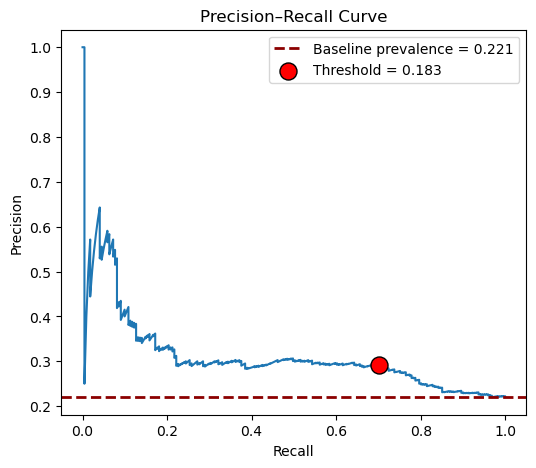

In [61]:
baseline = y_test.mean()

plt.figure(figsize=(6,5))

plt.plot(recall, precision)

plt.axhline(
    baseline,
    color="darkred",
    linestyle="--",
    linewidth=2,
    label=f"Baseline prevalence = {baseline:.3f}"
)

plt.scatter(
    recall[idx],
    precision[idx],
    color="red",
    s=150,
    edgecolor="black",
    linewidth=1,
    zorder=10,
    label=f"Threshold = {target_threshold:.3f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.legend()
plt.show()

# Saving Information for the DASH app

In [63]:
from pathlib import Path

ARTIFACT_DIR = Path("../Dash_App/App_Artifacts")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

In [65]:
import joblib

joblib.dump(
    best_xgb,
    ARTIFACT_DIR / "xgb_readmission_meds.joblib"
)

best_xgb.save_model(
    ARTIFACT_DIR / "xgb_readmission_meds.json"
)

In [66]:
import json

config = {
    "embedding_model": "emilyalsentzer/Bio_ClinicalBERT",
    "section": "medication_reconciliation",
    "threshold": float(best_threshold),
    "target_recall": 0.70,
    "precision": float(precision[idx]),
    "recall": float(recall[idx])
}

with open(
    ARTIFACT_DIR / "model_config.json",
    "w"
) as f:
    json.dump(config, f, indent=4)

In [70]:
import duckdb
from pathlib import Path

DB_PATH = Path("../mimic4_note.db").resolve()

con = duckdb.connect(
    str(DB_PATH),
    read_only=True
)

nlp_subset_readmit_sectioned = con.sql("""
SELECT *
FROM nlp_subset_readmit_sectioned
""").df()

In [71]:
sample_pos = (
    nlp_subset_readmit_sectioned
    .query("readmit_30d == 1")
    [
        ["subject_id", "readmit_30d", "medication_reconciliation"]
    ]
    .sample(5, random_state=321)
)

sample_neg = (
    nlp_subset_readmit_sectioned
    .query("readmit_30d == 0")
    [
        ["subject_id", "readmit_30d", "medication_reconciliation"]
    ]
    .sample(5, random_state=321)
)

sample_notes = pd.concat(
    [sample_pos, sample_neg]
)

sample_notes.to_parquet(
    ARTIFACT_DIR / "medication_examples.parquet",
    index=True
)

In [72]:
X_meds = data["X_meds"]

sample_embeddings = X_meds[sample_notes.index]

In [73]:
sample_notes.to_parquet(
    ARTIFACT_DIR / "medication_examples.parquet",
    index=True
)

np.save(
    ARTIFACT_DIR / "medication_example_embeddings.npy",
    sample_embeddings
)

In [74]:
print(sample_notes.shape)
print(sample_embeddings.shape)

(10, 3)
(10, 768)
